#  ToxiTube — YouTube Comment Toxicity Detector
##  Preprocessing & Vectorisation

**Objectif de ce notebook :**
- Nettoyer et normaliser les textes
- Vectoriser avec TF-IDF et FastText
- Créer les splits train/test
- Sauvegarder tous les objets pour `03_modeles_classiques.ipynb`

### Cellule 1 — Chargement du checkpoint

**Pourquoi recharger ?**
Chaque notebook est indépendant — les variables du notebook précédent
ne sont pas accessibles ici. On recharge le DataFrame sauvegardé
par `01_exploration.ipynb`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/checkpoints', exist_ok=True)

df = pd.read_csv('../data/checkpoints/df_after_exploration.csv')

print(f' df chargé — {df.shape}')
print(f'Colonnes : {list(df.columns)}')

 df chargé — (159571, 10)
Colonnes : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'is_toxic', 'text_length']


### Cellule 2 — Imports preprocessing

**Pourquoi ces librairies ?**
- `re` : expressions régulières pour nettoyer les URLs, balises HTML
- `emoji` : convertir ou supprimer les emojis
- `nltk` : tokenisation et stopwords anglais

In [13]:
import re
import emoji
import nltk

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
STOPWORDS_EN = set(stopwords.words('english'))

print(' Imports preprocessing OK')

 Imports preprocessing OK


### Cellule 3 — Fonction preprocess()

**Fonction modulaire avec paramètre `keep_emojis` :**
- `keep_emojis=True` → les emojis sont convertis en texte (😡 → `angry_face`)
- `keep_emojis=False` → les emojis sont supprimés

Cela nous permettra de **comparer les deux approches** et de mesurer
l'impact des emojis sur les performances.

In [21]:
def preprocess(text, keep_emojis=True, remove_stopwords=False):
    """
    Nettoie et normalise un commentaire texte.
    Args:
        text             : texte brut
        keep_emojis      : True = convertit emojis en texte, False = supprime
        remove_stopwords : True = supprime les stopwords anglais
    Returns:
        texte nettoyé (string)
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    if keep_emojis:
        text = emoji.demojize(text, delimiters=(' ', ' '))
    else:
        text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^a-z0-9\s_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if remove_stopwords:
        tokens = text.split()
        tokens = [t for t in tokens if t not in STOPWORDS_EN]
        text = ' '.join(tokens)
    return text

print(' Fonction preprocess() définie')
test = 'Check this out 😡 <b>IDIOT</b> visit http://spam.com !!'
print(f'\nOriginal     : {test}')
print(f'Avec emojis  : {preprocess(test, keep_emojis=True)}')
print(f'Sans emojis  : {preprocess(test, keep_emojis=False)}')

 Fonction preprocess() définie

Original     : Check this out 😡 <b>IDIOT</b> visit http://spam.com !!
Avec emojis  : check this out enraged_face idiot visit
Sans emojis  : check this out idiot visit


### Cellule 4 — Application du preprocessing

**On applique la fonction sur les 159k commentaires dans deux versions :**
- `text_clean` (avec emojis convertis) → version principale pour TF-IDF et FastText
- `text_clean_no_emoji` (sans emojis) → version comparative
- `text_raw` → texte original intact pour BERT



In [28]:
print('Application du preprocessing... (1-2 min)')

df['text_clean'] = df['comment_text'].apply(
    lambda x: preprocess(x, keep_emojis=True)
)
df['text_clean_no_emoji'] = df['comment_text'].apply(
    lambda x: preprocess(x, keep_emojis=False)
)
df['text_raw'] = df['comment_text'].copy()

print(' Preprocessing terminé !')
print(f'\nExemple avant : {df["comment_text"].iloc[0][:100]}')
print(f'Exemple après : {df["text_clean"].iloc[0][:100]}')

Application du preprocessing... (1-2 min)
 Preprocessing terminé !

Exemple avant : Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't 
Exemple après : explanation why the edits made under my username hardcore metallica fan were reverted they weren t v


### Cellule 5 — Partie D : Analyse post-preprocessing

**Pourquoi analyser après preprocessing ?**
On vérifie que le nettoyage a bien fonctionné en visualisant
les mots les plus fréquents par classe.
Cela permet de valider que les mots-clés toxiques ressortent bien.

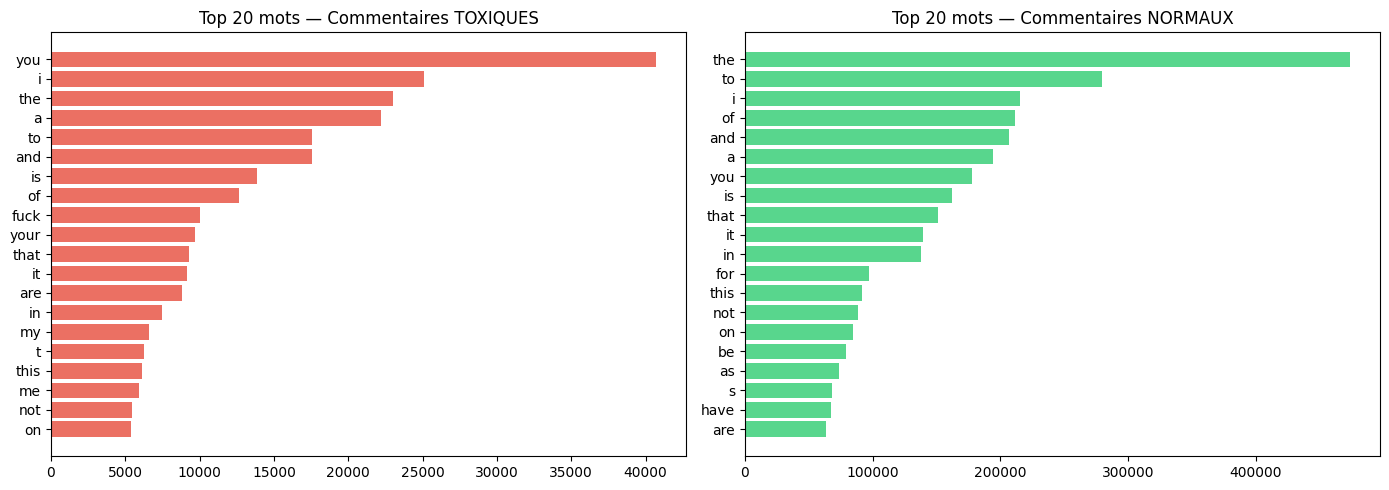

 Figure sauvegardée → figures/top_words.png


In [34]:
from collections import Counter

def top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

toxic_words  = top_words(df[df['is_toxic']==1]['text_clean'])
normal_words = top_words(df[df['is_toxic']==0]['text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words_t, counts_t = zip(*toxic_words)
axes[0].barh(list(words_t)[::-1], list(counts_t)[::-1], color='#e74c3c', alpha=0.8)
axes[0].set_title('Top 20 mots — Commentaires TOXIQUES')

words_n, counts_n = zip(*normal_words)
axes[1].barh(list(words_n)[::-1], list(counts_n)[::-1], color='#2ecc71', alpha=0.8)
axes[1].set_title('Top 20 mots — Commentaires NORMAUX')

plt.tight_layout()
plt.savefig('../figures/top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/top_words.png')

### Cellule 6 — Partie E : Vectorisation TF-IDF

**Qu'est-ce que TF-IDF ?**
TF-IDF transforme chaque commentaire en vecteur numérique basé sur la fréquence des mots.
- Un mot fréquent dans UN commentaire mais rare globalement → score élevé
- Un mot fréquent partout (`the`, `is`) → score faible

**Règle d'or :** On fit le TF-IDF UNIQUEMENT sur le train, jamais sur le test.
Fitter sur le test = data leakage = résultats artificiellement gonflés.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split stratifié AVANT vectorisation
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text_clean'],
    df['is_toxic'],
    test_size=0.2,
    random_state=42,
    stratify=df['is_toxic']
)

print(f'Train : {len(X_train_raw):,} exemples ({y_train.mean()*100:.1f}% toxiques)')
print(f'Test  : {len(X_test_raw):,} exemples ({y_test.mean()*100:.1f}% toxiques)')

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f'\n TF-IDF OK')
print(f'Shape train : {X_train_tfidf.shape}')
print(f'Shape test  : {X_test_tfidf.shape}')

Train : 127,656 exemples (10.2% toxiques)
Test  : 31,915 exemples (10.2% toxiques)

 TF-IDF OK
Shape train : (127656, 50000)
Shape test  : (31915, 50000)


### Cellule 7 — Chargement FastText

**Qu'est-ce que FastText ?**
Contrairement à TF-IDF qui ignore le sens des mots, FastText utilise des vecteurs
pré-entraînés sur des milliards de mots. Chaque mot est représenté par un vecteur
de 300 dimensions qui capture son sens sémantique.

Exemple : `terrible` et `awful` auront des vecteurs proches.


In [43]:
from gensim.models import KeyedVectors

FASTTEXT_SAVE_PATH = '../models/fasttext_en.kv'
os.makedirs('../models', exist_ok=True)

if not os.path.exists(FASTTEXT_SAVE_PATH):
    print(' Téléchargement via gensim downloader... (~960MB, 10-20 min)')
    import gensim.downloader as api
    ft_model = api.load('fasttext-wiki-news-subwords-300')
    ft_model.save(FASTTEXT_SAVE_PATH)
    print(' Sauvegardé dans models/fasttext_en.kv')
else:
    print(' Fichier local trouvé, chargement...')
    ft_model = KeyedVectors.load(FASTTEXT_SAVE_PATH)

ft_vectors = ft_model
print(f' FastText chargé — {len(ft_vectors):,} mots, dim={ft_vectors.vector_size}')

 Fichier local trouvé, chargement...
 FastText chargé — 999,999 mots, dim=300


### Cellule 8 — Calcul des embeddings FastText

**Notre approche :** On représente chaque commentaire par la **moyenne**
des vecteurs de tous ses mots connus.
Les mots absents du vocabulaire FastText sont ignorés.



In [46]:
def get_fasttext_vector(text):
    tokens = text.split()
    vectors = [ft_vectors[word] for word in tokens if word in ft_vectors]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(300)

print('Calcul embeddings train... (2-3 min)')
X_train_ft = np.vstack(X_train_raw.apply(get_fasttext_vector).values)

print('Calcul embeddings test...')
X_test_ft = np.vstack(X_test_raw.apply(get_fasttext_vector).values)

print(f'\n Embeddings FastText OK')
print(f'Shape train : {X_train_ft.shape}')
print(f'Shape test  : {X_test_ft.shape}')

Calcul embeddings train... (2-3 min)
Calcul embeddings test...

 Embeddings FastText OK
Shape train : (127656, 300)
Shape test  : (31915, 300)


### Cellule 9 — Sauvegarde des checkpoints

**Pourquoi sauvegarder autant d'objets ?**
Le notebook 03 a besoin de tout ceci pour entraîner les modèles.
On utilise `joblib` pour les matrices numpy/scipy (plus rapide que pickle)
et `csv` pour le DataFrame.

In [48]:
import joblib

# 1. df preprocessé
df.to_csv('../data/checkpoints/df_preprocessed.csv', index=False)

# 2. Vectoriseur TF-IDF fitté
joblib.dump(tfidf, '../data/checkpoints/tfidf.joblib')

# 3. Splits + embeddings
joblib.dump({
    'X_train_raw'  : X_train_raw,
    'X_test_raw'   : X_test_raw,
    'y_train'      : y_train,
    'y_test'       : y_test,
    'X_train_tfidf': X_train_tfidf,
    'X_test_tfidf' : X_test_tfidf,
    'X_train_ft'   : X_train_ft,
    'X_test_ft'    : X_test_ft,
}, '../data/checkpoints/splits.joblib')

print(' Tous les checkpoints sauvegardés :')
print('   → data/checkpoints/df_preprocessed.csv')
print('   → data/checkpoints/tfidf.joblib')
print('   → data/checkpoints/splits.joblib')

 Tous les checkpoints sauvegardés :
   → data/checkpoints/df_preprocessed.csv
   → data/checkpoints/tfidf.joblib
   → data/checkpoints/splits.joblib


###  Bilan Notebook 02

| Étape | Résultat |
|-------|----------|
| Preprocessing | `text_clean`, `text_clean_no_emoji`, `text_raw` créés |
| Split stratifié | Train 80% / Test 20% — proportion toxiques conservée |
| TF-IDF | Matrice (127,656 × 50,000) |
| FastText | Embeddings (127,656 × 300) |

**Prochain notebook :** `03_modeles_classiques.ipynb`